In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Ready!")

✅ Ready!


In [2]:
# Load the main transaction data
# Replace 'transactions.csv' with your actual file name
df = pd.read_csv('../data/raw/transactions.csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset shape: (95662, 16)
Columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [3]:
# Load the definitions for reference
definitions = pd.read_csv('../data/raw/Xente_Variable_Definitions.csv')
print("Variable Definitions:")
definitions

Variable Definitions:


,Column Name,Definition
0,TransactionId,Unique �transaction identifier on platform
1,BatchId,Unique number assigned to a batch of transacti...
2,AccountId,Unique number identifying the customer on plat...
3,SubscriptionId,Unique number identifying the customer subscri...
4,CustomerId,Unique identifier attached to Account
5,CurrencyCode,Country currency
6,CountryCode,Numerical geographical code of country
7,ProviderId,Source provider of Item �bought.
8,ProductId,Item name being bought.
9,ProductCategory,ProductIds are organized into these broader pr...


In [4]:
print("Dataset Info:")
print("="*50)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData types:")
print(df.dtypes.value_counts())

Dataset Info:
Rows: 95,662
Columns: 16

Memory usage: 66.48 MB

Data types:
object     11
int64       4
float64     1
Name: count, dtype: int64


In [5]:
missing = df.isnull().sum()
missing_pct = (missing/len(df))*100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False)

if len(missing_df) > 0:
    print("Missing Values Found:")
    print(missing_df)
else:
    print("✅ No missing values in the dataset!")

✅ No missing values in the dataset!


In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
print("Numerical Columns Summary:")
print("="*50)
df[numeric_cols].describe()

Numerical Columns Summary:


,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


Fraud Distribution:
FraudResult
0    95469
1      193
Name: count, dtype: int64

Fraud Rate: 0.20%


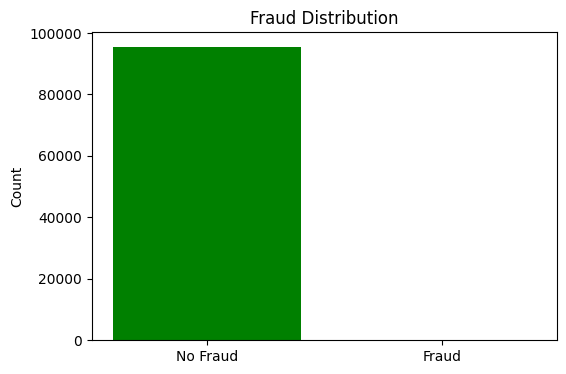

In [7]:
if 'FraudResult' in df.columns:
    fraud_counts = df['FraudResult'].value_counts()
    print("Fraud Distribution:")
    print(fraud_counts)
    print(f"\nFraud Rate: {fraud_counts[1]/len(df)*100:.2f}%")
    
    # Plot
    plt.figure(figsize=(6,4))
    plt.bar(['No Fraud', 'Fraud'], fraud_counts.values, color=['green', 'red'])
    plt.title('Fraud Distribution')
    plt.ylabel('Count')
    plt.show()

c:\Users\lenovo\credit-risk-model\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


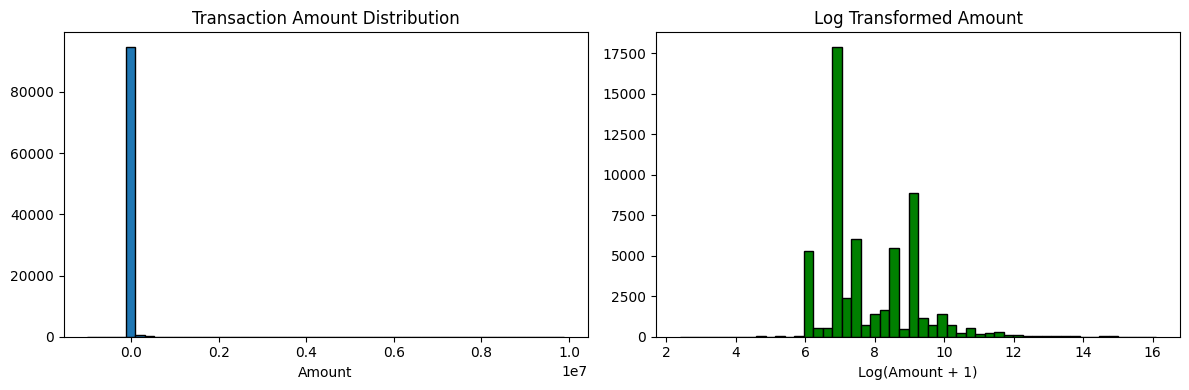

Amount Stats:
Mean: $6717.85
Median: $1000.00
Std: $123306.80
Min: $-1000000.00
Max: $9880000.00


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Regular
axes[0].hist(df['Amount'], bins=50, edgecolor='black')
axes[0].set_title('Transaction Amount Distribution')
axes[0].set_xlabel('Amount')

# Log transform
axes[1].hist(np.log1p(df['Amount']), bins=50, edgecolor='black', color='green')
axes[1].set_title('Log Transformed Amount')
axes[1].set_xlabel('Log(Amount + 1)')

plt.tight_layout()
plt.show()

print(f"Amount Stats:")
print(f"Mean: ${df['Amount'].mean():.2f}")
print(f"Median: ${df['Amount'].median():.2f}")
print(f"Std: ${df['Amount'].std():.2f}")
print(f"Min: ${df['Amount'].min():.2f}")
print(f"Max: ${df['Amount'].max():.2f}")

In [9]:
categorical_cols = ['ProductCategory', 'ChannelId', 'PricingStrategy']

for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col} Value Counts:")
        print(df[col].value_counts().head(10))
        print("-"*40)


ProductCategory Value Counts:
ProductCategory
financial_services    45405
airtime               45027
utility_bill           1920
data_bundles           1613
tv                     1279
ticket                  216
movies                  175
transport                25
other                     2
Name: count, dtype: int64
----------------------------------------

ChannelId Value Counts:
ChannelId
ChannelId_3    56935
ChannelId_2    37141
ChannelId_5     1048
ChannelId_1      538
Name: count, dtype: int64
----------------------------------------

PricingStrategy Value Counts:
PricingStrategy
2    79848
4    13562
1     1867
0      385
Name: count, dtype: int64
----------------------------------------


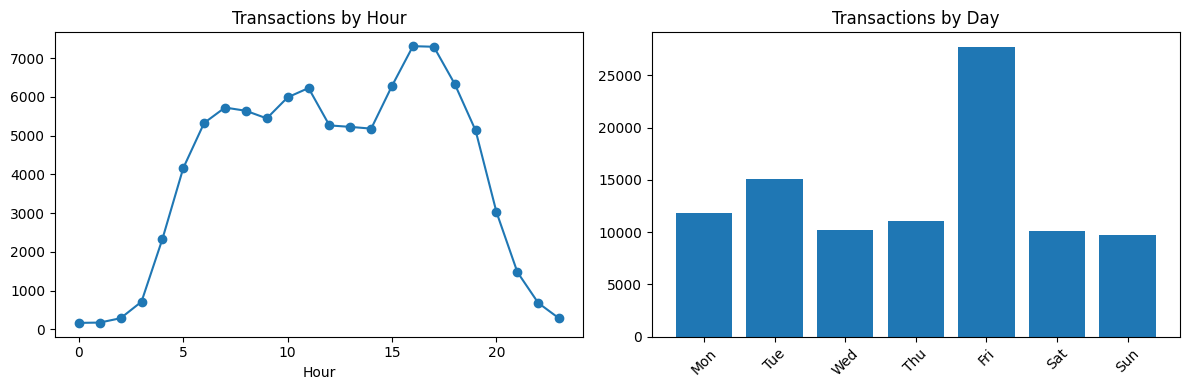

In [10]:
if 'TransactionStartTime' in df.columns:
    df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])
    df['Hour'] = df['TransactionStartTime'].dt.hour
    df['DayOfWeek'] = df['TransactionStartTime'].dt.dayofweek
    
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    
    # By hour
    hourly = df['Hour'].value_counts().sort_index()
    axes[0].plot(hourly.index, hourly.values, marker='o')
    axes[0].set_title('Transactions by Hour')
    axes[0].set_xlabel('Hour')
    
    # By day
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    daily = df['DayOfWeek'].value_counts().sort_index()
    axes[1].bar(days, daily.values)
    axes[1].set_title('Transactions by Day')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

Unique Customers: 3,742

Customer Transaction Stats:
       TransactionCount   TotalAmount     AvgAmount
count       3742.000000  3.742000e+03  3.742000e+03
mean          25.564404  1.717377e+05  1.571562e+04
std           96.929602  2.717305e+06  1.676991e+05
min            1.000000 -1.049000e+08 -4.250000e+05
25%            2.000000  4.077438e+03  1.000000e+03
50%            7.000000  2.000000e+04  2.583846e+03
75%           20.000000  7.996775e+04  4.877614e+03
max         4091.000000  8.345124e+07  8.601821e+06


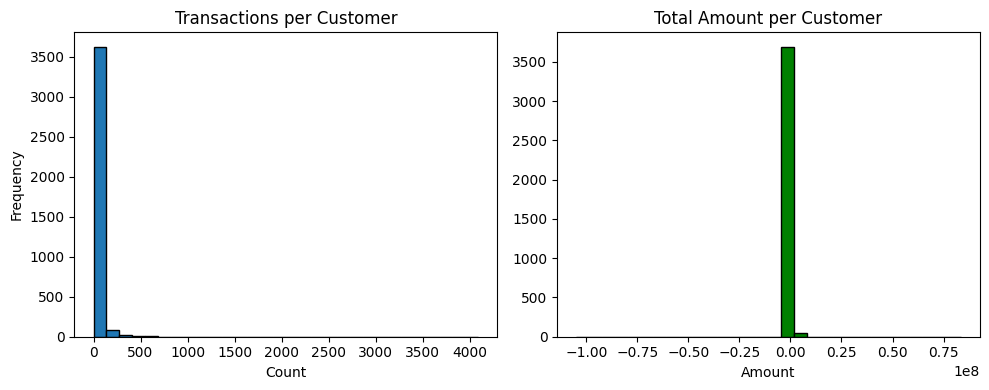

In [11]:
# Aggregate by customer
customer_data = df.groupby('CustomerId').agg({
    'TransactionId': 'count',
    'Amount': ['sum', 'mean']
})

customer_data.columns = ['TransactionCount', 'TotalAmount', 'AvgAmount']
customer_data = customer_data.reset_index()

print(f"Unique Customers: {customer_data.shape[0]:,}")
print("\nCustomer Transaction Stats:")
print(customer_data.describe())

# Distribution
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(customer_data['TransactionCount'], bins=30, edgecolor='black')
plt.title('Transactions per Customer')
plt.xlabel('Count')
plt.ylabel('Frequency')

plt.subplot(1,2,2)
plt.hist(customer_data['TotalAmount'], bins=30, edgecolor='black', color='green')
plt.title('Total Amount per Customer')
plt.xlabel('Amount')

plt.tight_layout()
plt.show()

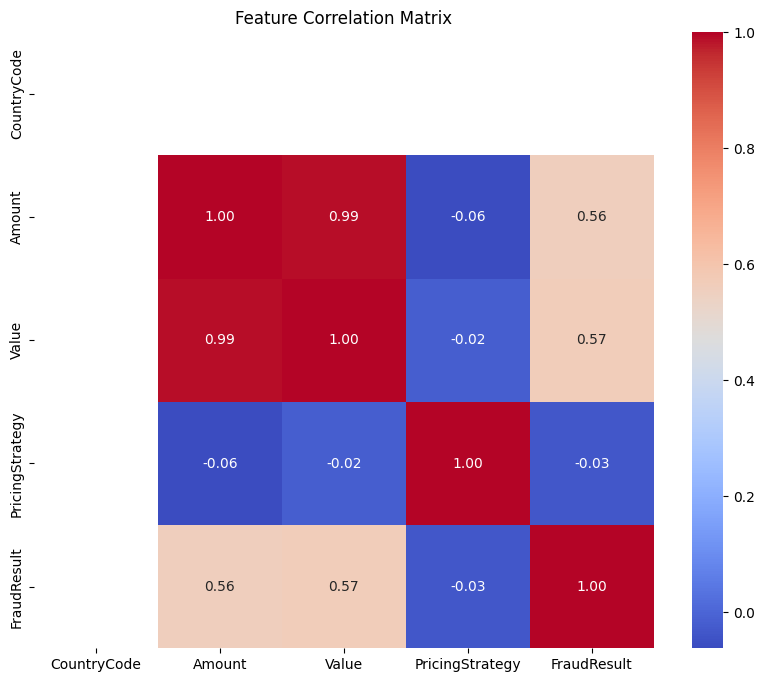

In [12]:
# Correlation only for numeric columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

In [14]:
print("="*60)
print("TOP 5 INSIGHTS FROM EDA")
print("="*60)

insights = [
    "1. Dataset has no missing values - clean and ready",
    "2. Amount distribution is highly skewed - needs log transform",
    f"3. Fraud rate is {df['FraudResult'].mean()*100:.2f}% - imbalanced",
    f"4. {customer_data.shape[0]:,} unique customers with varying transaction patterns",
    "5. Peak transaction hours: 10am-4pm (business hours)"
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
print("✓ Apply log transformation to Amount")
print("✓ Create RFM features per customer")
print("✓ Use class balancing for modeling")
print("✓ Extract time-based features (hour, weekend)")

TOP 5 INSIGHTS FROM EDA
1. 1. Dataset has no missing values - clean and ready
2. 2. Amount distribution is highly skewed - needs log transform
3. 3. Fraud rate is 0.20% - imbalanced
4. 4. 3,742 unique customers with varying transaction patterns
5. 5. Peak transaction hours: 10am-4pm (business hours)

RECOMMENDATIONS
✓ Apply log transformation to Amount
✓ Create RFM features per customer
✓ Use class balancing for modeling
✓ Extract time-based features (hour, weekend)


In [15]:
# Save for next tasks
output_path = '../data/processed/cleaned_data.parquet'
df.to_parquet(output_path)
print(f"✅ Data saved to: {output_path}")

✅ Data saved to: ../data/processed/cleaned_data.parquet
